# Python Notebook 2: Classification Modelling & Hyperparameter Tuning

Author: Santosh Manoharadas  
Student ID: w1954095 / 20220967  
Module: 5DATA002W.2 Machine Learning and Data Mining




## Section 1 - Import Libraries
Importing Classification and Evaluation Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, recall_score, precision_score,
    f1_score, roc_auc_score, roc_curve, ConfusionMatrixDisplay
)

sns.set_style('whitegrid')
import warnings
warnings.filterwarnings('ignore')

## Section 2 - Load Cleaned Dataset
Loading the Prepared Classification Dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/ML CWK/loan_classification_clean.csv')
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (58645, 11)


,age,income,home_ownership,emplyment_length,loan_intent,loan_amount,loan_interest_rate,loan_income_ratio,payment_default_on_file,credit_history_length,loan_approval_status
0,21.0,12000,2,0,1,15000,6.99,0.12,0,4,0
1,21.0,13200,2,2,1,25000,16.77,0.19,1,3,0
2,23.0,9600,3,5,3,30000,12.42,0.31,0,3,0
3,40.0,182004,3,3,1,35000,8.00,0.19,0,11,0
4,40.0,90000,0,3,2,35000,12.42,0.39,0,14,0


## Section 3 - Define Features and Target (Task 4b-i)
Defining Input Features and Target Variable

In [ ]:
X = df.drop(columns=['loan_approval_status'])
y = df['loan_approval_status']

print("Feature names used for classification:")
print(X.columns.tolist())
print(f"\nFeature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")

Feature names used for classification:
['age', 'income', 'home_ownership', 'emplyment_length', 'loan_intent', 'loan_amount', 'loan_interest_rate', 'loan_income_ratio', 'payment_default_on_file', 'credit_history_length']

Feature matrix shape: (58645, 10)
Target vector shape: (58645,)


## Section 4 - Train-Test Split (Task 4b-ii and 4b-iii)
Stratified Train-Test Split

In [ ]:
# random_state=42 ensures reproducibility and same test set for all models
# stratify=y ensures the class ratio is preserved in both splits
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")
print(f"\nClass ratio in training set:")
print(y_train.value_counts(normalize=True).round(4))
print(f"\nClass ratio in test set:")
print(y_test.value_counts(normalize=True).round(4))

Training set shape: (41051, 10)
Test set shape: (17594, 10)

Class ratio in training set:
loan_approval_status
0    0.8576
1    0.1424
Name: proportion, dtype: float64

Class ratio in test set:
loan_approval_status
0    0.8576
1    0.1424
Name: proportion, dtype: float64


## Section 5 - Feature Scaling
Applying StandardScaler to Features**



In [ ]:
scaler = StandardScaler()

# Fit the scaler on the training data ONLY, then transform both sets
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Scaled training set shape: {X_train_scaled.shape}")
print(f"Scaled test set shape: {X_test_scaled.shape}")

Scaled training set shape: (41051, 10)
Scaled test set shape: (17594, 10)


## Section 6 - Helper Function for Evaluation
Defining Evaluation Helper Function

In [ ]:
def evaluate_classifier(model, X_test, y_test, model_name):
    """
    Evaluates a fitted classifier on the test set.
    Prints confusion matrix, classification report, and plots ROC curve.
    Returns a dictionary of metric scores.
    """
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    # Compute individual evaluation metrics
    acc = accuracy_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred, pos_label=0)
    prec = precision_score(y_test, y_pred, pos_label=0)
    f1 = f1_score(y_test, y_pred, pos_label=0)
    auc = roc_auc_score(y_test, y_prob)

    print(f"{'='*50}")
    print(f" Model: {model_name}")
    print(f"{'='*50}")
    print(f" Accuracy  : {acc:.4f}")
    print(f" Recall    : {rec:.4f}")
    print(f" Precision : {prec:.4f}")
    print(f" F1-Score  : {f1:.4f}")
    print(f" AUC-ROC   : {auc:.4f}")
    print(f"{'='*50}\n")

    print("Classification Report:")
    print(classification_report(y_test, y_pred, target_names=['Rejected (0)', 'Approved (1)']))

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=['Rejected (0)', 'Approved (1)'])
    disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
    axes[0].set_title(f'{model_name} - Confusion Matrix', fontsize=11)

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    axes[1].plot(fpr, tpr, color='darkorange', lw=2,
                 label=f'ROC Curve (AUC = {auc:.4f})')
    axes[1].plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--', label='Random Classifier')
    axes[1].set_xlim([0.0, 1.0])
    axes[1].set_ylim([0.0, 1.05])
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].set_title(f'{model_name} - AUC-ROC Curve', fontsize=11)
    axes[1].legend(loc='lower right')

    plt.suptitle(f'Evaluation - {model_name}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    return {'Model': model_name, 'Accuracy': acc, 'Recall': rec,
            'Precision': prec, 'F1-Score': f1, 'AUC-ROC': auc}

print("Evaluation helper function defined.")

Evaluation helper function defined.


## Section 7 - Model 1: Naïve Bayes (NB)
Training and Evaluating Gaussian Naïve Bayes

 Model: Naïve Bayes (NB)
 Accuracy  : 0.8494
 Recall    : 0.8898
 Precision : 0.9316
 F1-Score  : 0.9102
 AUC-ROC   : 0.8594

Classification Report:
              precision    recall  f1-score   support

Rejected (0)       0.93      0.89      0.91     15089
Approved (1)       0.48      0.61      0.53      2505

    accuracy                           0.85     17594
   macro avg       0.70      0.75      0.72     17594
weighted avg       0.87      0.85      0.86     17594



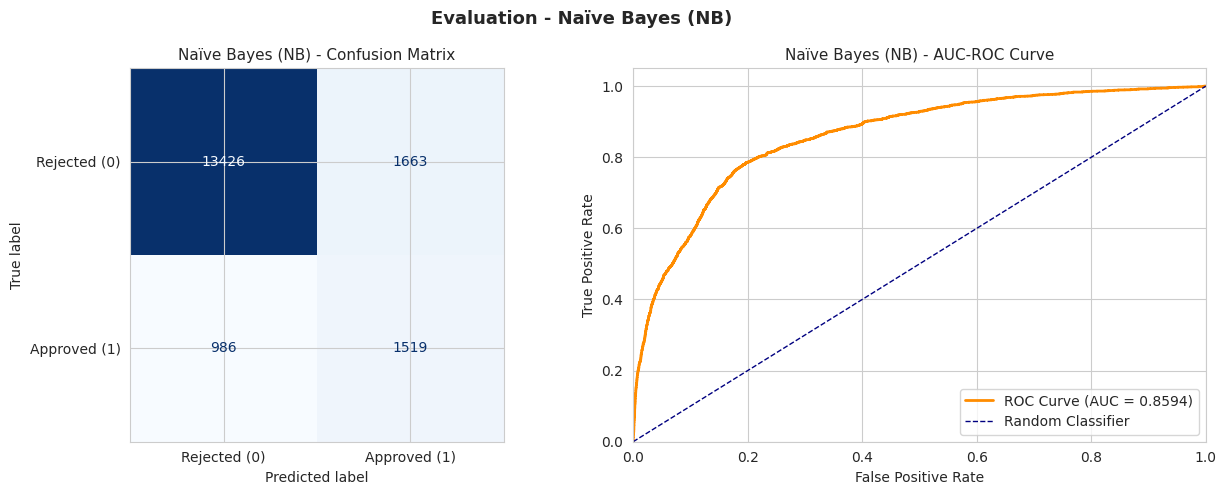

In [ ]:
# Initialise the Gaussian Naïve Bayes classifier (no key hyperparameters to tune here)
nb_model = GaussianNB()
nb_model.fit(X_train_scaled, y_train)
nb_results = evaluate_classifier(nb_model, X_test_scaled, y_test, 'Naïve Bayes (NB)')

## Section 8 - Model 2: Logistic Regression (LR)
Training and Evaluating Logistic Regression

 Model: Logistic Regression (LR)
 Accuracy  : 0.8927
 Recall    : 0.9760
 Precision : 0.9061
 F1-Score  : 0.9398
 AUC-ROC   : 0.8751

Classification Report:
              precision    recall  f1-score   support

Rejected (0)       0.91      0.98      0.94     15089
Approved (1)       0.73      0.39      0.51      2505

    accuracy                           0.89     17594
   macro avg       0.82      0.68      0.72     17594
weighted avg       0.88      0.89      0.88     17594



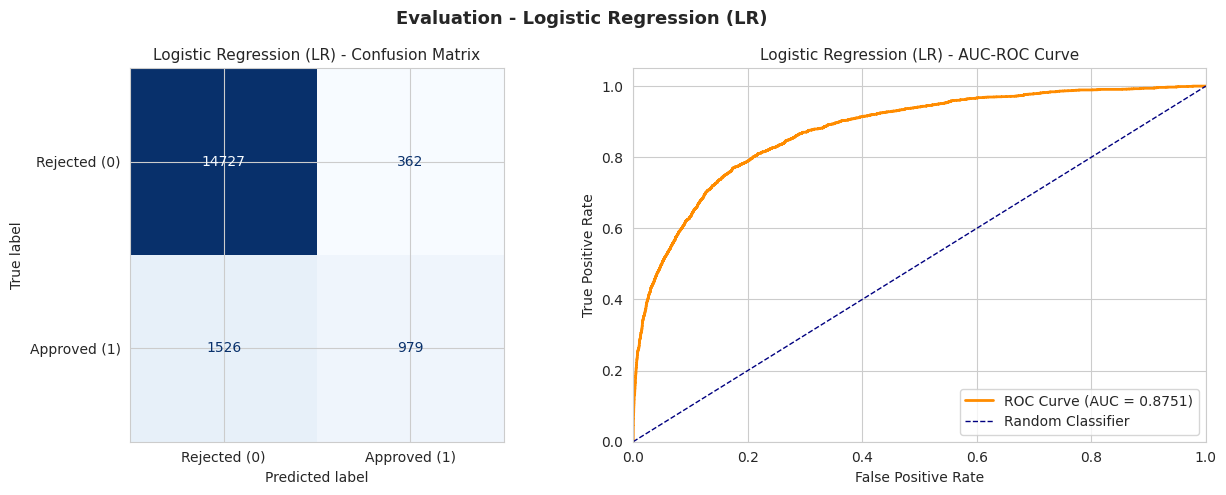

In [ ]:
# Initialise Logistic Regression with a maximum of 1000 iterations for convergence
# random_state=42 ensures reproducibility of results
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)
lr_results = evaluate_classifier(lr_model, X_test_scaled, y_test, 'Logistic Regression (LR)')

## Section 9 - Model 3: K-Nearest Neighbours (KNN)
Training and Evaluating KNN Classifier

Initial K value (sqrt heuristic): 202
Adjusted K (odd): 203
 Model: KNN (K=203)
 Accuracy  : 0.8980
 Recall    : 0.9928
 Precision : 0.8988
 F1-Score  : 0.9435
 AUC-ROC   : 0.8949

Classification Report:
              precision    recall  f1-score   support

Rejected (0)       0.90      0.99      0.94     15089
Approved (1)       0.88      0.33      0.48      2505

    accuracy                           0.90     17594
   macro avg       0.89      0.66      0.71     17594
weighted avg       0.90      0.90      0.88     17594



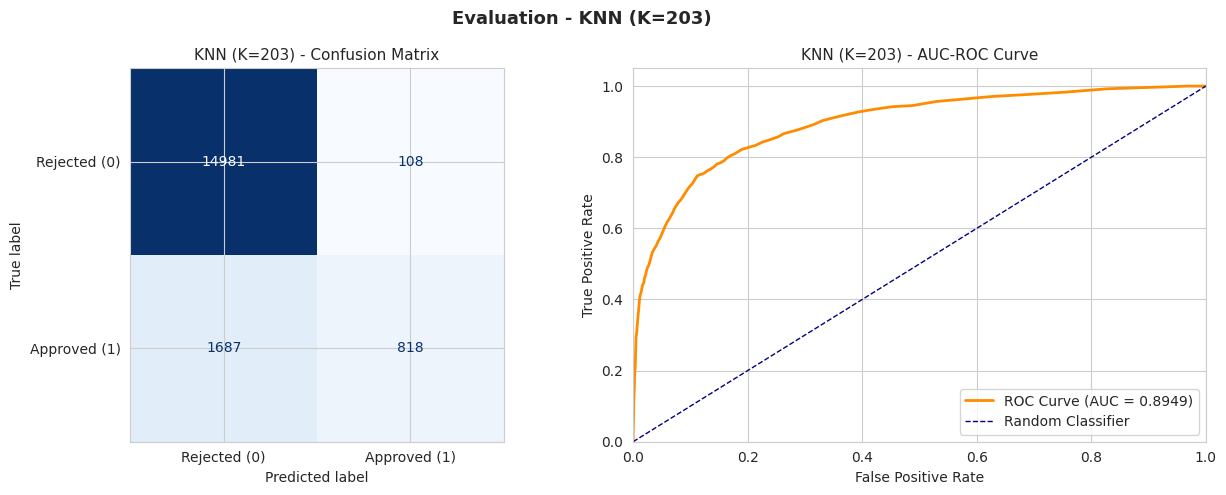

In [ ]:
# Determine initial K using the square root heuristic (common starting point)
k_initial = int(np.sqrt(len(X_train)))
print(f"Initial K value (sqrt heuristic): {k_initial}")

# Use the nearest odd number to avoid ties in binary classification
k_initial = k_initial if k_initial % 2 != 0 else k_initial + 1
print(f"Adjusted K (odd): {k_initial}")
knn_model = KNeighborsClassifier(n_neighbors=k_initial)
knn_model.fit(X_train_scaled, y_train)
knn_results = evaluate_classifier(knn_model, X_test_scaled, y_test, f'KNN (K={k_initial})')

## Section 10 - Model Comparison Summary (Task 5b)
Comparing All Model Evaluation Scores

In [ ]:
results_df = pd.DataFrame([nb_results, lr_results, knn_results])
results_df = results_df.set_index('Model')
results_df = results_df.round(4)
print("\n=== Model Performance Comparison (Test Set) ===")
print(results_df.to_string())


=== Model Performance Comparison (Test Set) ===
                          Accuracy  Recall  Precision  F1-Score  AUC-ROC
Model                                                                   
Naïve Bayes (NB)            0.8494  0.8898     0.9316    0.9102   0.8594
Logistic Regression (LR)    0.8927  0.9760     0.9061    0.9398   0.8751
KNN (K=203)                 0.8980  0.9928     0.8988    0.9435   0.8949


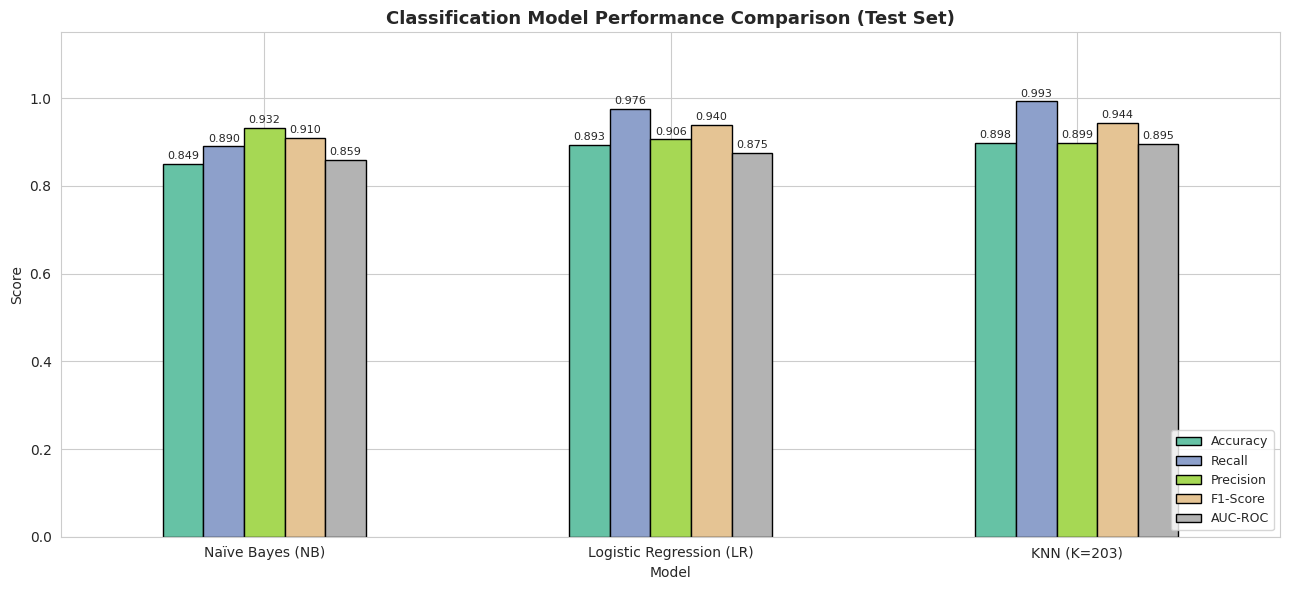

In [ ]:
ax = results_df.plot(kind='bar', figsize=(13, 6), colormap='Set2', edgecolor='black')
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', fontsize=8, padding=2)

ax.set_title('Classification Model Performance Comparison (Test Set)', fontsize=13, fontweight='bold')
ax.set_ylabel('Score')
ax.set_xlabel('Model')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(loc='lower right', fontsize=9)
ax.set_ylim(0, 1.15)
plt.tight_layout()
plt.show()

## Section 11 - Hyperparameter Tuning with GridSearchCV (Task 5d)
Hyperparameter Optimisation with GridSearchCV



In [ ]:
# C: inverse regularisation strength (smaller = stronger regularisation)
# penalty: regularisation type (l1 or l2)
# solver: optimisation algorithm
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']
}

from sklearn.metrics import make_scorer, recall_score

reject_recall = make_scorer(recall_score, pos_label=0)

grid_search_lr = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    param_grid=param_grid_lr,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring=reject_recall,
    n_jobs=-1,
    verbose=1
)

# Fit GridSearchCV on the scaled training data to find the best hyperparameters
grid_search_lr.fit(X_train_scaled, y_train)

print(f"\nBest Hyperparameters: {grid_search_lr.best_params_}")
print(f"Best CV Recall Score: {grid_search_lr.best_score_:.4f}")

Fitting 5 folds for each of 10 candidates, totalling 50 fits

Best Hyperparameters: {'C': 0.01, 'penalty': 'l1', 'solver': 'liblinear'}
Best CV Recall Score: 0.9780


 Model: LR Tuned (GridSearchCV)
 Accuracy  : 0.8924
 Recall    : 0.9779
 Precision : 0.9044
 F1-Score  : 0.9397
 AUC-ROC   : 0.8747

Classification Report:
              precision    recall  f1-score   support

Rejected (0)       0.90      0.98      0.94     15089
Approved (1)       0.74      0.38      0.50      2505

    accuracy                           0.89     17594
   macro avg       0.82      0.68      0.72     17594
weighted avg       0.88      0.89      0.88     17594



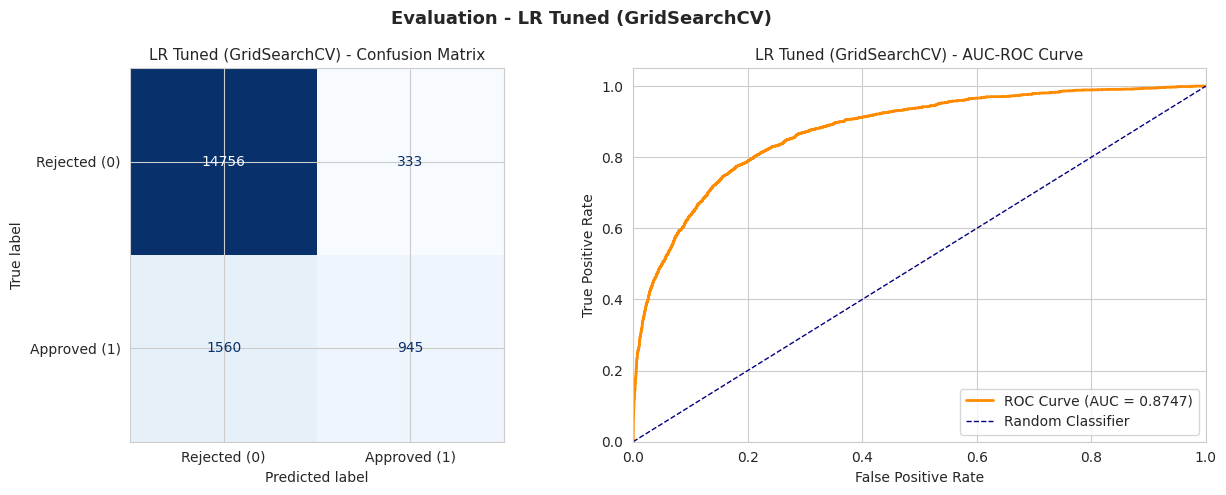


=== Before vs After Tuning ===
                          Accuracy  Recall  Precision  F1-Score  AUC-ROC
Model                                                                   
Logistic Regression (LR)    0.8927  0.9760     0.9061    0.9398   0.8751
LR Tuned (GridSearchCV)     0.8924  0.9779     0.9044    0.9397   0.8747


In [ ]:
lr_tuned = grid_search_lr.best_estimator_
lr_tuned_results = evaluate_classifier(lr_tuned, X_test_scaled, y_test, 'LR Tuned (GridSearchCV)')

print("\n=== Before vs After Tuning ===")
comparison = pd.DataFrame([lr_results, lr_tuned_results]).set_index('Model').round(4)
print(comparison.to_string())

## Section 12 - KNN Hyperparameter Tuning
Tuning KNN with GridSearchCV

Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best KNN Hyperparameters: {'metric': 'euclidean', 'n_neighbors': 5, 'weights': 'distance'}
Best CV Recall Score: 0.5317
 Model: KNN Tuned (GridSearchCV)
 Accuracy  : 0.9135
 Recall    : 0.9745
 Precision : 0.9282
 F1-Score  : 0.9508
 AUC-ROC   : 0.8587

Classification Report:
              precision    recall  f1-score   support

Rejected (0)       0.93      0.97      0.95     15089
Approved (1)       0.78      0.55      0.64      2505

    accuracy                           0.91     17594
   macro avg       0.85      0.76      0.80     17594
weighted avg       0.91      0.91      0.91     17594



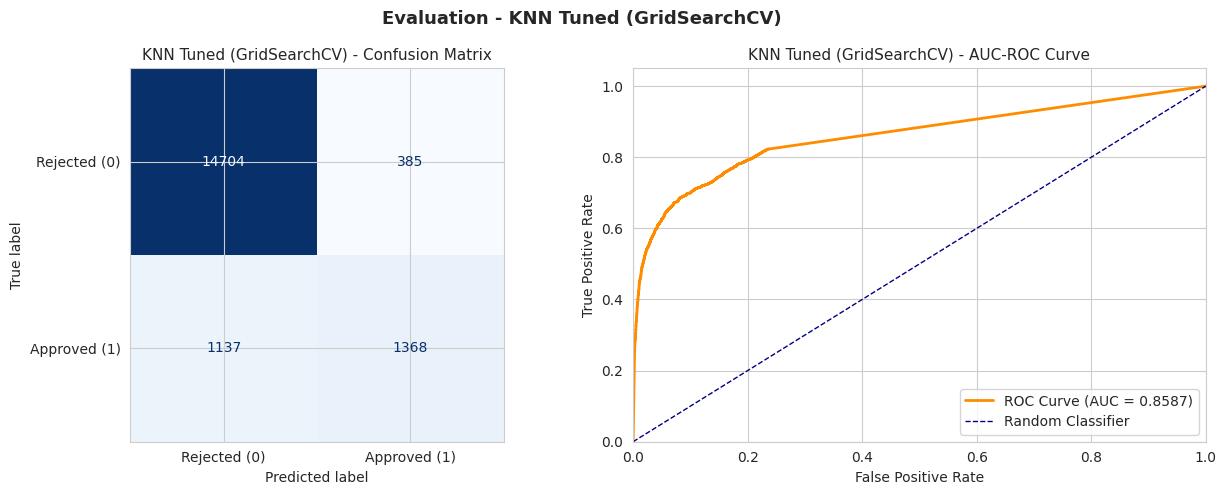

In [ ]:
# n_neighbors: number of nearest neighbours to consider
# weights: how to weight neighbours (uniform or by distance)
# metric: distance measure used
param_grid_knn = {
    'n_neighbors': [5, 11, 21, 31, 51],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}
grid_search_knn = GridSearchCV(
    KNeighborsClassifier(),
    param_grid=param_grid_knn,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='recall',
    n_jobs=-1,
    verbose=1
)
grid_search_knn.fit(X_train_scaled, y_train)

print(f"\nBest KNN Hyperparameters: {grid_search_knn.best_params_}")
print(f"Best CV Recall Score: {grid_search_knn.best_score_:.4f}")

knn_tuned = grid_search_knn.best_estimator_
knn_tuned_results = evaluate_classifier(knn_tuned, X_test_scaled, y_test, 'KNN Tuned (GridSearchCV)')

## Section 13 - Final Model Summary
Final Comparison Table

In [ ]:
all_results = pd.DataFrame([
    nb_results, lr_results, knn_results, lr_tuned_results, knn_tuned_results
]).set_index('Model').round(4)

print("\n=== Final Classification Model Comparison ===")
print(all_results.to_string())

best_model_name = all_results['Recall'].idxmax()
print(f"Best model by Reject Recall: {best_model_name} ({all_results.loc[best_model_name, 'Recall']:.4f})")


=== Final Classification Model Comparison ===
                          Accuracy  Recall  Precision  F1-Score  AUC-ROC
Model                                                                   
Naïve Bayes (NB)            0.8494  0.8898     0.9316    0.9102   0.8594
Logistic Regression (LR)    0.8927  0.9760     0.9061    0.9398   0.8751
KNN (K=203)                 0.8980  0.9928     0.8988    0.9435   0.8949
LR Tuned (GridSearchCV)     0.8924  0.9779     0.9044    0.9397   0.8747
KNN Tuned (GridSearchCV)    0.9135  0.9745     0.9282    0.9508   0.8587
Best model by Reject Recall: KNN (K=203) (0.9928)


In [ ]:
all_results.to_csv('classification_results_summary.csv')
print("Classification results saved as: classification_results_summary.csv")

from google.colab import files
files.download('classification_results_summary.csv')

Classification results saved as: classification_results_summary.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### References
- Géron, A. (2019) *Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow*. 2nd edn. O'Reilly Media.
